### Importing the libraries

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# This section includes the necessary imports for data manipulation (pandas), text processing (re, nltk), 
# machine learning (sklearn), and visualization (matplotlib, seaborn).

### 2. Dataset Loading and Exploration

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')

print(df['sentiment'].value_counts())   #This part loads the IMDB Dataset.csv and checks the distribution of positive and
# negative sentiment labels.

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


### 3. Data Cleaning and Preprocessing

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<br />', ' ', text) # Remove HTML
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    
    #  Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    
    return " ".join(filtered_words)

df['cleaned_review'] = df['review'].apply(preprocess_text)
# The code defines a preprocess_text function to convert text to lowercase, remove HTML tags,
#  eliminate punctuation/numbers, and filter out stopwords.

### 4. Feature Extraction (TF-IDF Vectorization)

In [ ]:
tfidf = TfidfVectorizer(max_features=5000) # Only keep the top 5000 most important words
X = tfidf.fit_transform(df['cleaned_review']).toarray()
y = df['sentiment'].map({'positive': 1, 'negative': 0}) # Encode labels
# In this step, the cleaned reviews are converted into numerical features using the TfidfVectorizer with a maximum of 5,000 features.

### 5. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes: {X_test.shape}, {y_test.shape}")
# The data is divided into training (80%) and testing (20%) sets to evaluate the performance of the models.

Training shapes: (40000, 5000), (40000,)
Testing shapes: (10000, 5000), (10000,)


### 6. Model Initialization and Training

In [ ]:
# 1. Initialize the models
lr_model = LogisticRegression()
nb_model = MultinomialNB()

# 2. Train the models
lr_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
# Two machine learning models, Logistic Regression and Multinomial Naive Bayes, are initialized and trained on the TF-IDF features.
print("Training complete!")

Training complete!


### 7. Model Evaluation

In [ ]:
# Make predictions
lr_preds = lr_model.predict(X_test)
nb_preds = nb_model.predict(X_test)

# Print the "Report Card" for Logistic Regression
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, lr_preds))

# Print the "Report Card" for Naive Bayes
print("\n--- Naive Bayes Performance ---")
print(classification_report(y_test, nb_preds)) # The performance of both models is assessed using classification reports,
# which include precision, recall, and F1-score.

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


--- Naive Bayes Performance ---
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



### 8. Confusion Matrix

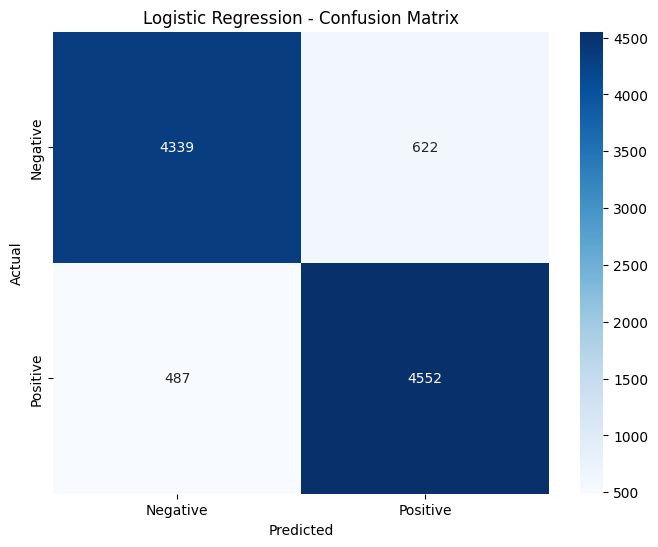

In [8]:
cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

### 9. Model Persistence (Saving the Models)

In [ ]:
import pickle

# Save the Vectorizer
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

# Save both models
pickle.dump(lr_model, open('lr_model.pkl', 'wb'))
pickle.dump(nb_model, open('nb_model.pkl', 'wb'))